# TP 1 : les moindres carrés et le ridge

Ajuster un modèle linéaire à la main, puis regarder ce que deux mesures presque identiques font
à ses coefficients.

## 1.0 Deux estimateurs sur les mêmes patients

442 patients diabétiques, dix mesures prises au départ, et une cible : la progression de la
maladie un an plus tard, de 25 à 346.

Le même modèle linéaire s'ajuste de deux façons. Le **maximum de vraisemblance** n'écoute que les
données et se ramène aux moindres carrés. Le **maximum a posteriori** y ajoute la croyance que les
coefficients sont petits, et se ramène au ridge. Ce TP les construit toutes les deux à la main, sur
ces patients, et compare ce qu'elles rendent.

Deux des dix mesures se ressemblent beaucoup : `s1` le cholestérol total et `s2` le LDL, qui en est
une composante. On verra que cette ressemblance décide de presque tout ce qui suit.

Les colonnes sont `age`, `sex`, `bmi` (indice de masse corporelle), `bp` (tension), puis six
analyses sanguines `s1` à `s6`. **`s1` est le cholestérol total, `s2` le LDL** ; et le LDL est
une composante du cholestérol total.

Chaque colonne a été centrée puis divisée par sa norme : elles valent toutes entre $-0{,}2$ et
$0{,}2$, avec un écart-type de $1/\sqrt{442} \approx 0{,}048$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

data = load_diabetes(as_frame=True)
feature_names = list(data.data.columns)
X, y = data.data.values, data.target.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"{len(X_train)} patients d'entraînement, {len(X_test)} de test, "
      f"{X.shape[1]} mesures : {', '.join(feature_names)}")
data.data.describe().loc[["min", "max", "std"]].round(3)

353 patients d'entraînement, 89 de test, 10 mesures : age, sex, bmi, bp, s1, s2, s3, s4, s5, s6


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048


## 1.1 L'équation normale

Le modèle prédit un score linéaire. Pour ne pas traîner le biais $w_0$ dans toutes les formules,
on ajoute aux données une colonne fictive qui vaut toujours $1$ :

$$h_w(x) = w^T x = w_0 \cdot 1 + w_1 x_1 + \dots + w_n x_n,
  \qquad x = (1, x_1, \dots, x_n) \in \mathbb{R}^{n+1}.$$

On empile les $m$ entrées augmentées comme lignes de la **matrice de conception**
$X \in \mathbb{R}^{m \times (n+1)}$, et on cherche le $w$ qui minimise la somme des carrés :

$$J(w) = \sum_{i=1}^{m} \big(w^T x^{(i)} - y^{(i)}\big)^2 = \lVert Xw - y \rVert^2 .$$

Annuler $\nabla_w J = 2X^T(Xw - y)$ donne l'**équation normale** :

$$\boxed{\ X^T X\, w = X^T y, \qquad w = (X^T X)^{-1} X^T y\ }$$

On la résout comme un système linéaire, avec `np.linalg.solve(A, b)`, plutôt qu'en inversant
$X^T X$ puis en multipliant.

**Q1.** `X_train` a 353 lignes et 10 colonnes, et on ajoute devant une colonne qui vaut
toujours $1$. Combien de nombres le modèle apprend-il ? Ce compte changerait-il avec un million de
patients ?

**Réponse attendue :** Onze nombres : un biais et dix poids. La colonne de $1$ ajoute un paramètre aux dix mesures, donc
$w \in \mathbb{R}^{11}$.

Non, ce compte ne changerait pas avec un million de patients. Il est fixé par le nombre de colonnes,
pas par le nombre de lignes : $X^T X$ reste une matrice $11 \times 11$, et le système à résoudre
reste le même. Des patients en plus ne donnent pas au modèle davantage de choses à apprendre, ils
donnent davantage de contraintes pour déterminer les mêmes onze.

Attention, « dix » oublie la colonne de $1$, qui porte le biais et compte comme un paramètre. Et un
compte qui grandirait avec le nombre de patients confondrait la taille des données avec la taille du
modèle : les lignes servent à déterminer les paramètres, elles n'en ajoutent pas.

*Pour aller plus loin :* avec un million de lignes, ce qui coûte est le produit $X^T X$, qui
parcourt toutes les données ; la résolution du système $11 \times 11$, elle, est négligeable.

In [2]:
def design_matrix(X):
    """Add the dummy feature x_0 = 1 as the first column."""
    return np.hstack([np.ones((len(X), 1)), X])


def normal_equation(X, y):
    """Least-squares weights, bias first."""
    A = design_matrix(X)
    return np.linalg.solve(A.T @ A, A.T @ y)


w = normal_equation(X_train, y_train)
reference = LinearRegression().fit(X_train, y_train)
assert design_matrix(X_train).shape == (353, 11)
assert np.allclose(design_matrix(X_train)[:, 0], 1.0)
assert np.isclose(w[0], reference.intercept_)
assert np.allclose(w[1:], reference.coef_)


def predict(X, w):
    return design_matrix(X) @ w


def cost(X, y, w):
    """J(w), the sum of squared errors."""
    return np.sum((predict(X, w) - y) ** 2)


def r2(y, y_hat):
    return 1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2)


assert np.allclose(predict(X_test, w), reference.predict(X_test))
assert np.isclose(r2(y_test, predict(X_test, w)), reference.score(X_test, y_test))
# the normal equation is exactly the w that minimises J: nudging any weight can only raise it
nudged = w.copy()
nudged[3] += 1.0
assert cost(X_train, y_train, w) < cost(X_train, y_train, nudged)

print(f"R² d'entraînement {r2(y_train, predict(X_train, w)):.3f}, "
      f"R² de test {r2(y_test, predict(X_test, w)):.3f}")
print(f"coût d'entraînement J(w) = {cost(X_train, y_train, w):,.0f}".replace(",", " "))
print()
print(pd.DataFrame({"coefficient": w[1:]}, index=feature_names).round(1).to_string())

correlations = pd.DataFrame(X_train, columns=feature_names).corr()
print(f"\ncorrélation entre s1 (cholestérol total) et s2 (LDL) : {correlations.loc['s1', 's2']:.3f}")

R² d'entraînement 0.554, R² de test 0.332
coût d'entraînement J(w) = 965 367

     coefficient
age        -35.6
sex       -243.2
bmi        562.8
bp         305.5
s1        -662.7
s2         324.2
s3          24.7
s4         170.3
s5         731.6
s6          43.0

corrélation entre s1 (cholestérol total) et s2 (LDL) : 0.889


## 1.2 Rétrécir sans annuler

On ajoute au coût une pénalité sur la taille des poids :

$$J(w) = \lVert Xw - y \rVert^2 + \lambda \lVert w_{1:n} \rVert^2 ,$$

ce qui déplace l'équation normale d'un multiple de l'identité :

$$\boxed{\ w = (X^T X + \lambda I)^{-1} X^T y\ }$$

C'est la **régression ridge**. Le biais $w_0$ n'est pas pénalisé (rien ne justifie de tirer vers
zéro le niveau moyen de la cible), donc le coin $(0,0)$ de $I$ vaut $0$.

**Q2.** L'a priori se résume à « avant de voir les données, je crois les coefficients petits », et
il ajoute au coût la somme de leurs carrés. Les moindres carrés rendent des coefficients allant
jusqu'à 732 : que va leur faire cette pénalité ?

**Réponse attendue :** Elle va les rétrécir, et d'autant plus qu'ils sont gros : c'est la somme de leurs **carrés** qui est
pénalisée, donc un coefficient de 700 pèse cent fois plus qu'un coefficient de 70. On attend donc
que les plus grosses valeurs fondent le plus, et que `s1` et `s2`, qui sont parmi elles, soient
franchement rabotés.

Le mécanisme : la pénalité $L_2$ **est** l'a priori gaussien $w \sim
\mathcal{N}(0, \tau^2 I)$, écrit du côté de l'optimisation, avec $\lambda = \sigma^2/\tau^2$. Ce que
le modèle minimise n'est plus seulement l'écart aux cibles, c'est cet écart plus une mesure de
l'invraisemblance des coefficients au regard de cette croyance.

Attention, la pénalité ne divise pas tous les coefficients par le même facteur. Un même $\lambda$
s'applique bien à tous les poids, mais le coût en carrés fait céder les gros bien avant les petits.
Le tableau le montrera : `bmi` perd à peu près la moitié du sien, `s1` en perd la quasi-totalité.

In [3]:
def ridge_equation(X, y, lam):
    """Ridge weights, bias first. The bias is not penalised."""
    A = design_matrix(X)
    penalty = lam * np.eye(A.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(A.T @ A + penalty, A.T @ y)


w_ridge = ridge_equation(X_train, y_train, 1.0)
reference_ridge = Ridge(alpha=1.0).fit(X_train, y_train)
assert np.isclose(w_ridge[0], reference_ridge.intercept_)
assert np.allclose(w_ridge[1:], reference_ridge.coef_)
assert np.allclose(ridge_equation(X_train, y_train, 0.0), w)

comparison = pd.DataFrame({"moindres carrés": w[1:], "ridge λ = 1": w_ridge[1:]},
                          index=feature_names)
print(comparison.round(0).to_string())

print(f"\nR² de test : moindres carrés {r2(y_test, predict(X_test, w)):.3f}, "
      f"ridge {r2(y_test, predict(X_test, w_ridge)):.3f}")

     moindres carrés  ridge λ = 1
age            -36.0         21.0
sex           -243.0        -73.0
bmi            563.0        301.0
bp             305.0        177.0
s1            -663.0          3.0
s2             324.0        -35.0
s3              25.0       -156.0
s4             170.0        118.0
s5             732.0        257.0
s6              43.0        102.0

R² de test : moindres carrés 0.332, ridge 0.341


**Q3.** Sous la pénalité, le coefficient de `s1` passe de $-663$ à 3, tandis que `bmi` ne perd que
la moitié du sien. Qu'est-ce qui distingue ces deux mesures, pour que la pénalité les traite si
différemment ?

**Réponse attendue :** Ce qui les distingue, c'est que `bmi` est seule à porter ce qu'elle porte, tandis que `s1` a une
jumelle. `s1` et `s2` corrèlent à 0,889 : les deux colonnes disent presque la même chose, donc la
somme de leurs carrés peut fondre sans que les prédictions en souffrent, et la pénalité s'en saisit.
`bmi` n'a pas ce luxe : réduire son coefficient de moitié se paie immédiatement en erreur, d'où les
301 qui restent.

Les chiffres de l'asymétrie : `bmi` passe de 563 à 301 et `s5` de 732 à 257, ils perdent la moitié
ou les deux tiers et restent les plus gros ; `s1` passe de $-663$ à 3, deux cents fois moins. Et le
$R^2$ de test n'y perd rien, 0,341 contre 0,332 : ce qui a cédé n'était pas ce qui servait à
prédire.

Ce qu'il faut en conclure sur le $-663$ : il n'était pas déterminé par les données, puisque la seule
croyance que les coefficients sont petits a suffi à l'effacer sans contrepartie. Il ne faut pas pour
autant conclure que le cholestérol total n'a pas d'effet ; la conclusion porte sur ce que ces 353
patients permettent d'établir, pas sur la biologie.

Attention, il ne suffit pas de dire que la pénalité frappe les gros coefficients et que `s1` était
le deuxième plus gros : `s5` était plus gros encore, et il est resté. Ce qui décide n'est pas la
taille du coefficient, c'est ce que coûte sa réduction.

## 1.3 Choisir $\lambda$

$\lambda$ ne s'apprend pas sur les données d'entraînement : à $\lambda = 0$ le coût
d'entraînement est toujours le plus bas. C'est un **hyperparamètre**, et on le choisit sur une
partie mise de côté, la **validation**, découpée dans l'entraînement ; le test reste fermé.

**Q4.** On va tracer l'erreur de validation pour $\lambda$ allant de $10^{-4}$ à $10^{4}$.
Va-t-elle monter sans arrêt, ou descendre puis remonter, et pourquoi ?

**Réponse attendue :** Descendre puis remonter : un U, c'est la forme attendue. Tant que $\lambda$ reste petit, la pénalité
ne coupe que des directions que les données ne déterminaient pas (celle de Q4) et l'erreur de
validation peut baisser. Passé un certain point, elle rétrécit aussi les coefficients qui servaient
réellement à prédire, et l'erreur remonte : un $\lambda$ trop grand est mauvais, pour la raison
opposée à un $\lambda$ trop petit.

Ce que la sortie donne pourtant : le $\lambda$ retenu sur ce découpage est $10^{-4}$, le plus petit
de la grille. Sur ces 89 patients de validation, le U n'a pas de branche gauche visible : la courbe
est quasi plate et son minimum tombe au bord. L'intuition de la forme est la bonne, elle n'est
simplement pas franche ici : sur ces données, tout $\lambda$ entre $10^{-4}$ et 1 se vaut à peu
près.

Attention à ne pas confondre cette courbe avec celle de l'erreur d'entraînement, qui elle monte sans
arrêt : $\lambda = 0$ est par définition le minimum du coût d'entraînement, donc toute pénalité ne
peut que dégrader l'ajustement sur les patients qui ont servi à l'ajuster. Les deux courbes sont sur
la même figure, et c'est celle de validation qui a le droit de descendre.

*Pour aller plus loin :* sur la figure de gauche, les coefficients partent de leurs valeurs des
moindres carrés et se rapprochent tous de zéro à mesure que $\lambda$ monte, les plus instables en
premier et le plus brutalement. À la limite, il ne reste que le biais, qui n'est pas pénalisé : le
modèle prédit la moyenne d'entraînement pour n'importe quelle entrée.

λ retenu sur la validation : 0.0001
RMSE de validation : 55.07 à ce λ, 55.07 à λ = 0.0001, 79.03 à λ = 10000

λ = 0        R² de test 0.332
λ = 0.0001   R² de test 0.332
λ = 1        R² de test 0.341
λ = 10       R² de test 0.141
λ = 100      R² de test 0.019


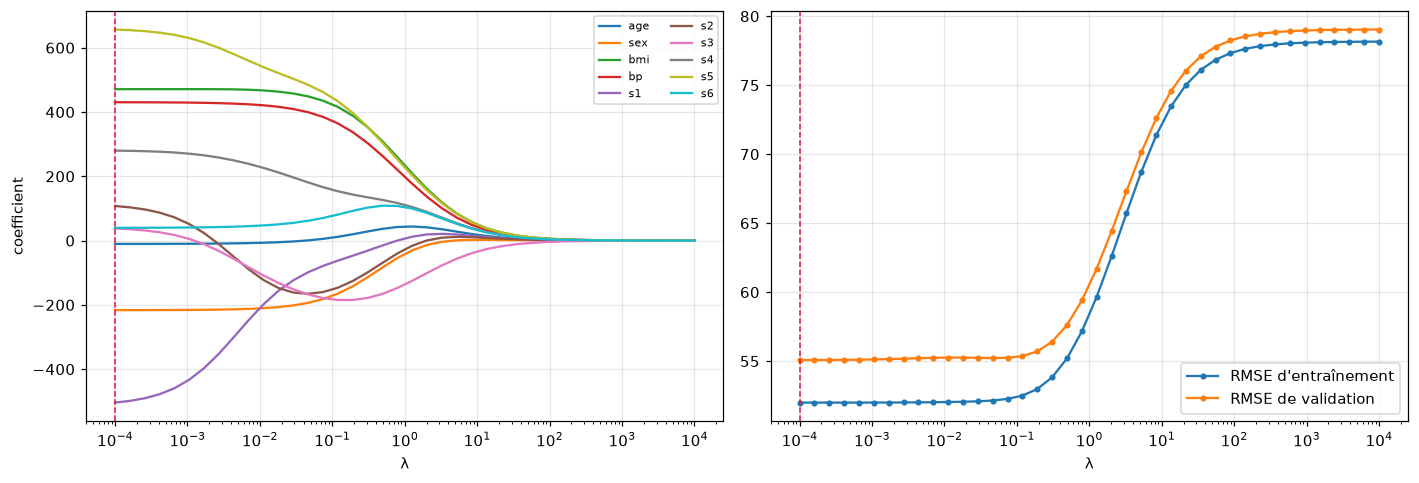

In [4]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0)
lambdas = np.logspace(-4, 4, 40)


def rmse(X, y, w):
    return np.sqrt(np.mean((predict(X, w) - y) ** 2))


paths, rmse_fit, rmse_val = [], [], []
for lam in lambdas:
    w_lam = ridge_equation(X_fit, y_fit, lam)
    paths.append(w_lam[1:])
    rmse_fit.append(rmse(X_fit, y_fit, w_lam))
    rmse_val.append(rmse(X_val, y_val, w_lam))

paths = np.array(paths)
assert paths.shape == (40, 10)
assert np.allclose(paths[0], ridge_equation(X_fit, y_fit, lambdas[0])[1:])
assert np.isclose(rmse(X_test, y_test, w), np.sqrt(np.mean((predict(X_test, w) - y_test) ** 2)))

best = lambdas[int(np.argmin(rmse_val))]
print(f"λ retenu sur la validation : {best:.4g}")
print(f"RMSE de validation : {min(rmse_val):.2f} à ce λ, "
      f"{rmse_val[0]:.2f} à λ = {lambdas[0]:.4g}, {rmse_val[-1]:.2f} à λ = {lambdas[-1]:.0f}")
print()
for lam in (0.0, best, 1.0, 10.0, 100.0):
    print(f"λ = {lam:<8.4g} R² de test {r2(y_test, predict(X_test, ridge_equation(X_train, y_train, lam))):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for j, name in enumerate(feature_names):
    axes[0].plot(lambdas, paths[:, j], label=name)
axes[0].set_xscale("log")
axes[0].axvline(best, color="crimson", ls="--", lw=1)
axes[0].set_xlabel("λ")
axes[0].set_ylabel("coefficient")
axes[0].legend(fontsize=7, ncol=2)
axes[1].plot(lambdas, rmse_fit, "o-", ms=3, label="RMSE d'entraînement")
axes[1].plot(lambdas, rmse_val, "o-", ms=3, label="RMSE de validation")
axes[1].set_xscale("log")
axes[1].axvline(best, color="crimson", ls="--", lw=1)
axes[1].set_xlabel("λ")
axes[1].legend()
plt.tight_layout()
plt.show()

**Q5.** Sur la figure de droite, la RMSE d'entraînement ne fait que monter avec $\lambda$.
Pourquoi ne peut-elle pas servir à choisir $\lambda$ ?

**Réponse attendue :** Parce qu'elle répond toujours la même chose : $\lambda = 0$. Une courbe qui ne fait que monter a son
minimum au bord de la grille, et ce minimum est connu d'avance : sans pénalité, l'ajustement sur les
patients d'entraînement est le meilleur possible, par définition du coût qu'on a minimisé. Un
critère qui désigne toujours la même valeur ne choisit rien.

Le fond de l'affaire : la pénalité est là précisément pour ne pas suivre ce critère. Choisir
$\lambda$ sur l'entraînement, c'est demander au modèle de noter sa propre copie ; il faut des
patients qu'il n'a pas vus, et c'est le rôle de la validation.

Attention, il ne suffit pas de dire que l'erreur d'entraînement est trop optimiste. Le problème
n'est pas qu'elle soit basse, c'est qu'elle range les $\lambda$ dans un ordre fixé d'avance, sans
rapport avec ce que le modèle fera sur de nouveaux patients.

*Pour aller plus loin :* la courbe de validation, elle, ne montre pas un U bien net : elle est quasi
plate sur plusieurs décades, avec un minimum à peine marqué. Le $\lambda$ retenu est donc peu
déterminé, et la sortie le confirme en le plaçant au bord de la grille.

## 1.4 Trois cibles, une seule inversion

Rien n'oblige la cible à être un seul nombre. Pour prédire $K$ valeurs à la fois, chaque sortie
reçoit sa colonne de paramètres, $W \in \mathbb{R}^{(n+1) \times K}$, et les cibles s'empilent en
lignes de $Y \in \mathbb{R}^{m \times K}$ :

$$\boxed{\ h_W(x) = W^T x \in \mathbb{R}^K, \qquad W = (X^T X)^{-1} X^T Y\ }$$

`load_linnerud` donne 20 sportifs, trois exercices en entrée (tractions, abdominaux, sauts) et
trois mesures physiologiques en sortie (poids, tour de taille, pouls).

**Q6.** Dans $W = (X^T X)^{-1} X^T Y$, le facteur $(X^T X)^{-1}$ ne dépend pas de $Y$. Que
coûtent alors les trois régressions, comparées à une seule ?

**Réponse attendue :** À peine plus qu'une seule. Le facteur $(X^T X)^{-1}$, la partie coûteuse, ne dépend que des
entrées : on le calcule une fois et on le réutilise pour les trois sorties. Il ne reste, par sortie,
qu'un produit avec une colonne de $Y$. C'est pour cela qu'un seul `np.linalg.solve` suffit pour les
trois sorties, avec $Y$ à la place de $y$ : trois régressions ne coûtent pas trois fois une
régression.

La partie chère ne concerne que $X$. Ajouter une quatrième sortie, ou une centième, ne change
presque rien au temps de calcul tant que les entrées restent les mêmes.

Attention, répondre « trois fois plus, une régression par sortie » revient à décrire ce que fait
`W_separate` dans le code : l'`assert` montre qu'il obtient exactement le même résultat, pour trois
fois le travail.

*Pour aller plus loin :* ce partage est purement calculatoire. Les colonnes de $W$ sont
indépendantes, donc prédire le poids n'aide en rien à prédire le pouls : le modèle partage les
entrées, pas ce qu'il apprend. C'est précisément ce que changent les réseaux de neurones, en
partageant des représentations intermédiaires entre les sorties.

In [5]:
linnerud = load_linnerud(as_frame=True)
X_sport, Y_sport = linnerud.data.values, linnerud.target.values
print(f"{X_sport.shape[0]} sportifs, entrées {list(linnerud.data.columns)}, "
      f"sorties {list(linnerud.target.columns)}")

A = design_matrix(X_sport)
W = np.linalg.solve(A.T @ A, A.T @ Y_sport)

# the same K regressions, fitted one target at a time
W_separate = np.column_stack([normal_equation(X_sport, Y_sport[:, k])
                              for k in range(Y_sport.shape[1])])
assert W.shape == (4, 3)
assert np.allclose(W, W_separate)
assert np.allclose(W[0], LinearRegression().fit(X_sport, Y_sport).intercept_)

print()
print(pd.DataFrame(W.round(3), index=["biais"] + list(linnerud.data.columns),
                   columns=list(linnerud.target.columns)).to_string())

20 sportifs, entrées ['Chins', 'Situps', 'Jumps'], sorties ['Weight', 'Waist', 'Pulse']

         Weight   Waist   Pulse
biais   208.234  40.598  52.044
Chins    -0.475  -0.137   0.001
Situps   -0.218  -0.040   0.042
Jumps     0.093   0.028  -0.029


**Q7.** Le tableau donne les coefficients des trois exercices pour `Weight`, ajustés sur vingt
sportifs. Ces coefficients sont ceux du maximum de vraisemblance : que faut-il en craindre, avec
vingt lignes seulement ?

**Réponse attendue :** Le surapprentissage, auquel le maximum de vraisemblance est exposé par construction. Vingt
sportifs pour trois entrées, et ces entrées sont presque certainement corrélées entre elles : qui
fait beaucoup de tractions fait beaucoup d'abdominaux. Rien ne retient l'ajustement de sortir des
coefficients qui collent à ces vingt lignes-là, et chacun serait de toute façon un coefficient
partiel, à lire « à abdominaux et sauts fixés ».

Ce qu'on peut y opposer : le même ajustement avec un $\lambda$, donc avec la croyance que les
coefficients sont petits. Ici l'`assert` compare $W$ aux trois ajustements séparés du maximum de
vraisemblance, mais rien n'empêche de reprendre `ridge_equation` sur $Y$ : la forme close est la
même, à $\lambda$ près.

Attention enfin à ce que le code ne dit pas : les `assert` passent, les formules sont exactes, le
tableau s'imprime proprement, et rien de tout cela ne garantit ce qu'on peut conclure des nombres
obtenus. Un calcul juste sur vingt lignes reste un calcul juste sur vingt lignes.